# Mobile Money Loan Eligibility and Loan Amount Prediction

## Hybrid Machine Learning Project: Supervised and Unsupervised Learning

### Project Theme
This notebook develops a machine learning system that predicts:

1. Whether a mobile money customer is eligible for a loan.
2. The loan amount or loan limit the customer may qualify for.
3. The customer risk group using unsupervised clustering.

The project is inspired by mobile money credit services such as MoKash, where customer transaction behavior can be used to estimate creditworthiness.

---

## Research Problem

Mobile money loan providers need reliable ways to decide whether a customer should receive a loan and how much should be given. A poor decision may lead to financial loss if risky customers are approved. A very strict system may also reject good customers.

This project uses both supervised and unsupervised machine learning to support loan decision-making.

---

## Machine Learning Methods Used

### Unsupervised Learning
Used for customer segmentation and risk grouping.

1. K-Means Clustering
2. Gaussian Mixture Model
3. Agglomerative Clustering

### Supervised Learning for Loan Eligibility
Used to predict whether a customer qualifies for a loan.

1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier
4. Gradient Boosting Classifier
5. Support Vector Machine
6. K-Nearest Neighbors Classifier

### Supervised Learning for Loan Amount Prediction
Used to predict the amount a customer is eligible to borrow.

1. Linear Regression
2. Ridge Regression
3. Decision Tree Regressor
4. Random Forest Regressor
5. Gradient Boosting Regressor
6. K-Nearest Neighbors Regressor

---

## Important Note

If the dataset does not contain real loan approval and repayment labels, this notebook creates simulated academic targets using transparent financial rules. This is acceptable for coursework, but the limitation must be stated clearly in the report.

# Lecture-Aligned Notebook Improvements

This notebook has been improved to follow the machine learning workflow covered in class:

- **Introduction to ML**: separates supervised learning, unsupervised learning, classification, and regression.
- **EDA and Feature Engineering**: includes missing-value checks, distributions, outlier checking, pairplots, and heatmaps.
- **Regression**: predicts loan amount using MAE, RMSE, R², residual plots, and actual-vs-predicted plots.
- **Classification**: predicts loan eligibility using accuracy, precision, recall, F1-score, ROC-AUC, confusion matrices, and ROC curves.
- **Logistic Regression and SVM**: included as supervised classification algorithms.
- **Tree-Based Models**: Decision Tree, Random Forest, and Gradient Boosting are included and interpreted using feature importance.
- **Unsupervised Learning**: K-Means, Gaussian Mixture Model, and Agglomerative Clustering are compared.
- **Model Selection**: heatmaps and ranking tables are used to select the best model instead of relying only on accuracy.

# 1. Import Required Libraries

In [61]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import cupy as cp
import matplotlib.pyplot as plt
import seaborn as sns

# GPU dataframe library
import cudf

# GPU machine learning libraries
from cuml.model_selection import train_test_split
from cuml.preprocessing import StandardScaler
from cuml.cluster import KMeans
from cuml.decomposition import PCA as cuPCA

# sklearn metrics
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# sklearn models (CPU — cuML does not support all of these)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering

# cuML GPU models (used where supported)
from cuml.linear_model import LogisticRegression as cuLogisticRegression

# XGBoost with GPU support
from xgboost import XGBClassifier, XGBRegressor

RANDOM_STATE = 42

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [62]:
!nvidia-smi

Tue May 26 12:49:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             32W /   70W |    6781MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# 2. Load Dataset

Place your dataset in the same folder as this notebook and name it:

```text
assignment_dataset.csv
```

The notebook is designed for a mobile money transaction dataset with columns such as:

- `step`
- `type`
- `amount`
- `nameOrig`
- `oldbalanceOrg`
- `newbalanceOrig`
- `nameDest`
- `oldbalanceDest`
- `newbalanceDest`

If your dataset has extra columns such as `isFraud` or `isFlaggedFraud`, they will be removed because this project is about loan eligibility, not fraud detection.

# 3. Initial Data Inspection

In [63]:
DATA_PATH = "/kaggle/input/datasets/ealaxi/paysim1/PS_20174392719_1491204439457_log.csv"

# if not os.path.exists(DATA_PATH):
#     raise FileNotFoundError(
#         "assignment_dataset.csv was not found. "
#         "Put the CSV file in the same folder as this notebook, then run again."
#     )


for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        
df = pd.read_csv(DATA_PATH)
print("Dataset shape:", df.shape)
df.head()


/kaggle/input/datasets/ealaxi/paysim1/PS_20174392719_1491204439457_log.csv
/kaggle/input/datasets/prajwaldongre/loan-application-and-transaction-fraud-detection/loan_applications.csv
/kaggle/input/datasets/prajwaldongre/loan-application-and-transaction-fraud-detection/transactions.csv
Dataset shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [64]:
print("Columns in dataset:")
print(df.columns.tolist())

print("\nDataset information:")
display(df.info())

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Columns in dataset:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


None


Missing values:


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


Duplicate rows: 0


# 4. Data Cleaning

This section removes irrelevant columns, handles duplicates, and prepares the dataset for feature engineering.

In [65]:
df_clean = df.copy()

# Remove fraud-related columns if present because the assignment focuses on loan eligibility.
drop_cols = ["isFraud", "isFlaggedFraud"]
df_clean = df_clean.drop(columns=[c for c in drop_cols if c in df_clean.columns], errors="ignore")

# Remove exact duplicate rows.
df_clean = df_clean.drop_duplicates()

# Ensure important numeric columns exist.
required_numeric_cols = [
    "amount", "oldbalanceOrg", "newbalanceOrig",
    "oldbalanceDest", "newbalanceDest"
]

missing_required = [c for c in required_numeric_cols if c not in df_clean.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

# Fill missing numeric values with 0.
for col in required_numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce").fillna(0)

# If transaction type exists, fill missing values.
if "type" in df_clean.columns:
    df_clean["type"] = df_clean["type"].fillna("UNKNOWN")

print("Cleaned dataset shape:", df_clean.shape)
df_clean.head()

# Convert to GPU DataFrame for faster processing
df_clean = cudf.from_pandas(df_clean)
print("Converted to cuDF GPU DataFrame.")


Cleaned dataset shape: (6362620, 9)
Converted to cuDF GPU DataFrame.


# 5. Exploratory Data Analysis

This section helps us understand the transaction behavior before building models.

In [66]:
df_clean.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08


# Enhanced EDA Graphs

These visualizations strengthen the exploratory data analysis stage. They help identify missing values, outliers, distributions, and relationships between transaction variables before machine learning models are trained.

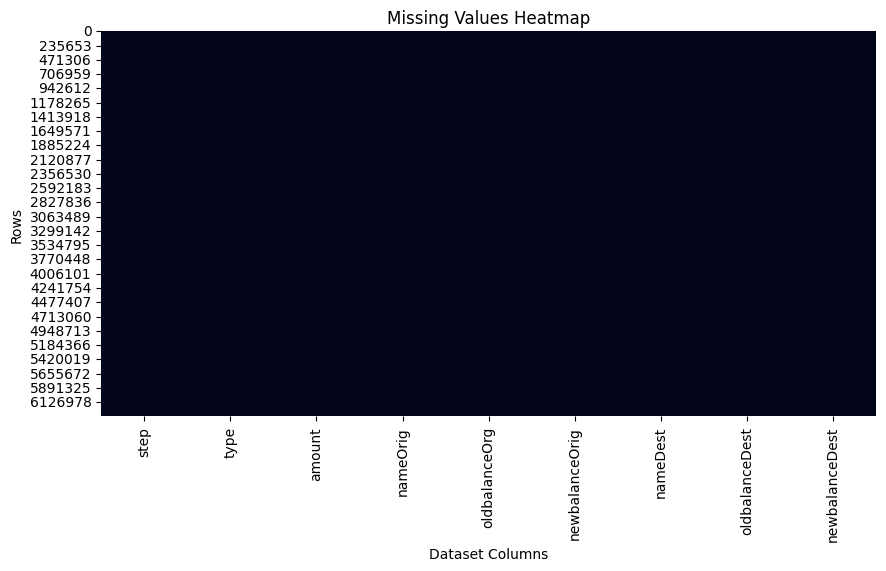

In [67]:
# Missing value heatmap
df_plot = df_clean.to_pandas()
plt.figure(figsize=(10, 5))
sns.heatmap(df_plot.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.xlabel("Dataset Columns")
plt.ylabel("Rows")
plt.show()

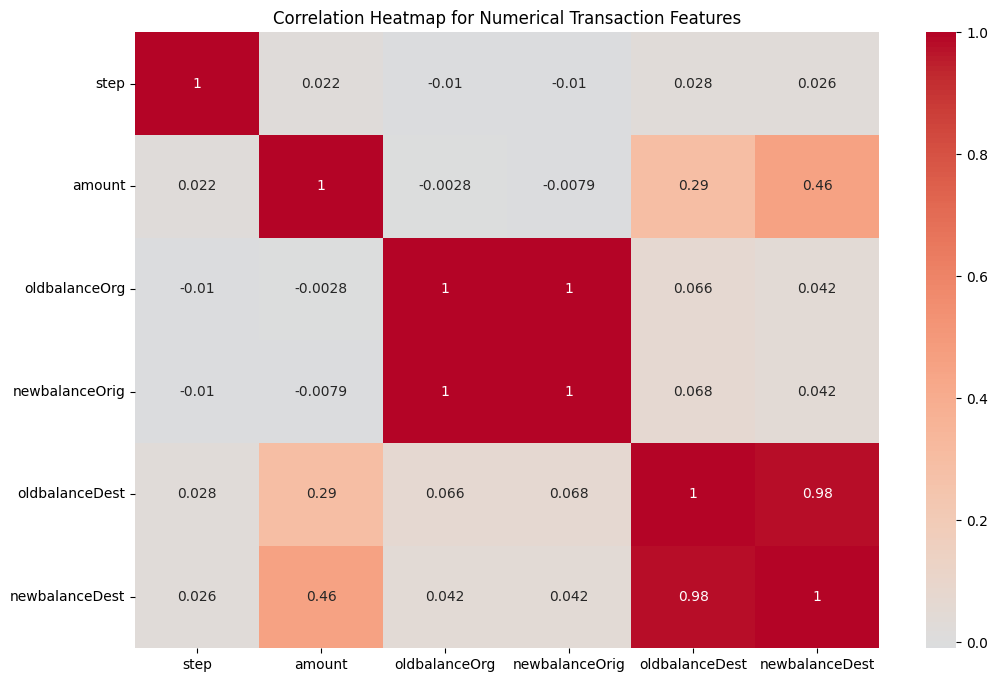

In [68]:
# Correlation heatmap for numeric variables
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(12, 8))
corr_matrix = df_plot[numeric_cols].corr()
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=True)
plt.title("Correlation Heatmap for Numerical Transaction Features")
plt.show()

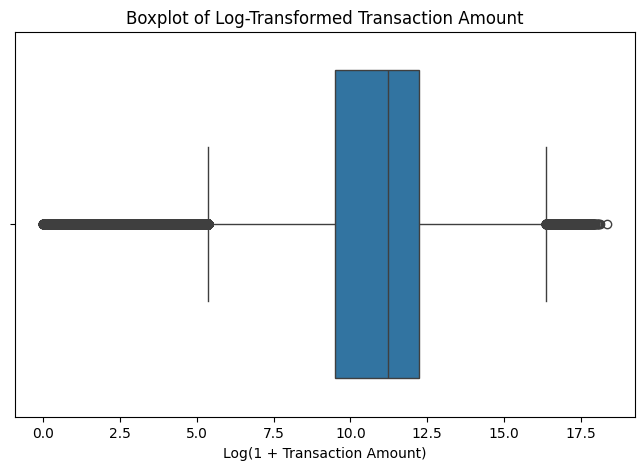

In [69]:
# Outlier checking using transaction amount boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x=np.log1p(df_plot["amount"]))
plt.title("Boxplot of Log-Transformed Transaction Amount")
plt.xlabel("Log(1 + Transaction Amount)")
plt.show()

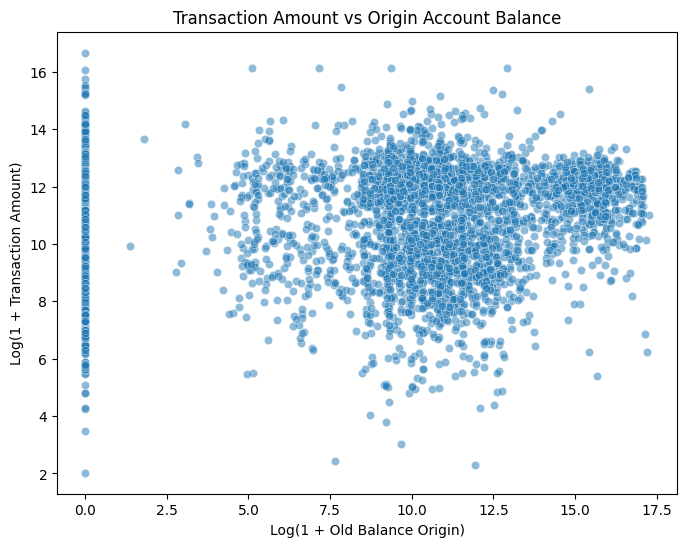

In [70]:
# Scatter plot: account balance vs transaction amount
sample_plot_df = df_plot.sample(n=min(5000, len(df_clean)), random_state=RANDOM_STATE)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=np.log1p(sample_plot_df["oldbalanceOrg"].clip(lower=0)),
    y=np.log1p(sample_plot_df["amount"].clip(lower=0)),
    alpha=0.5
)
plt.title("Transaction Amount vs Origin Account Balance")
plt.xlabel("Log(1 + Old Balance Origin)")
plt.ylabel("Log(1 + Transaction Amount)")
plt.show()

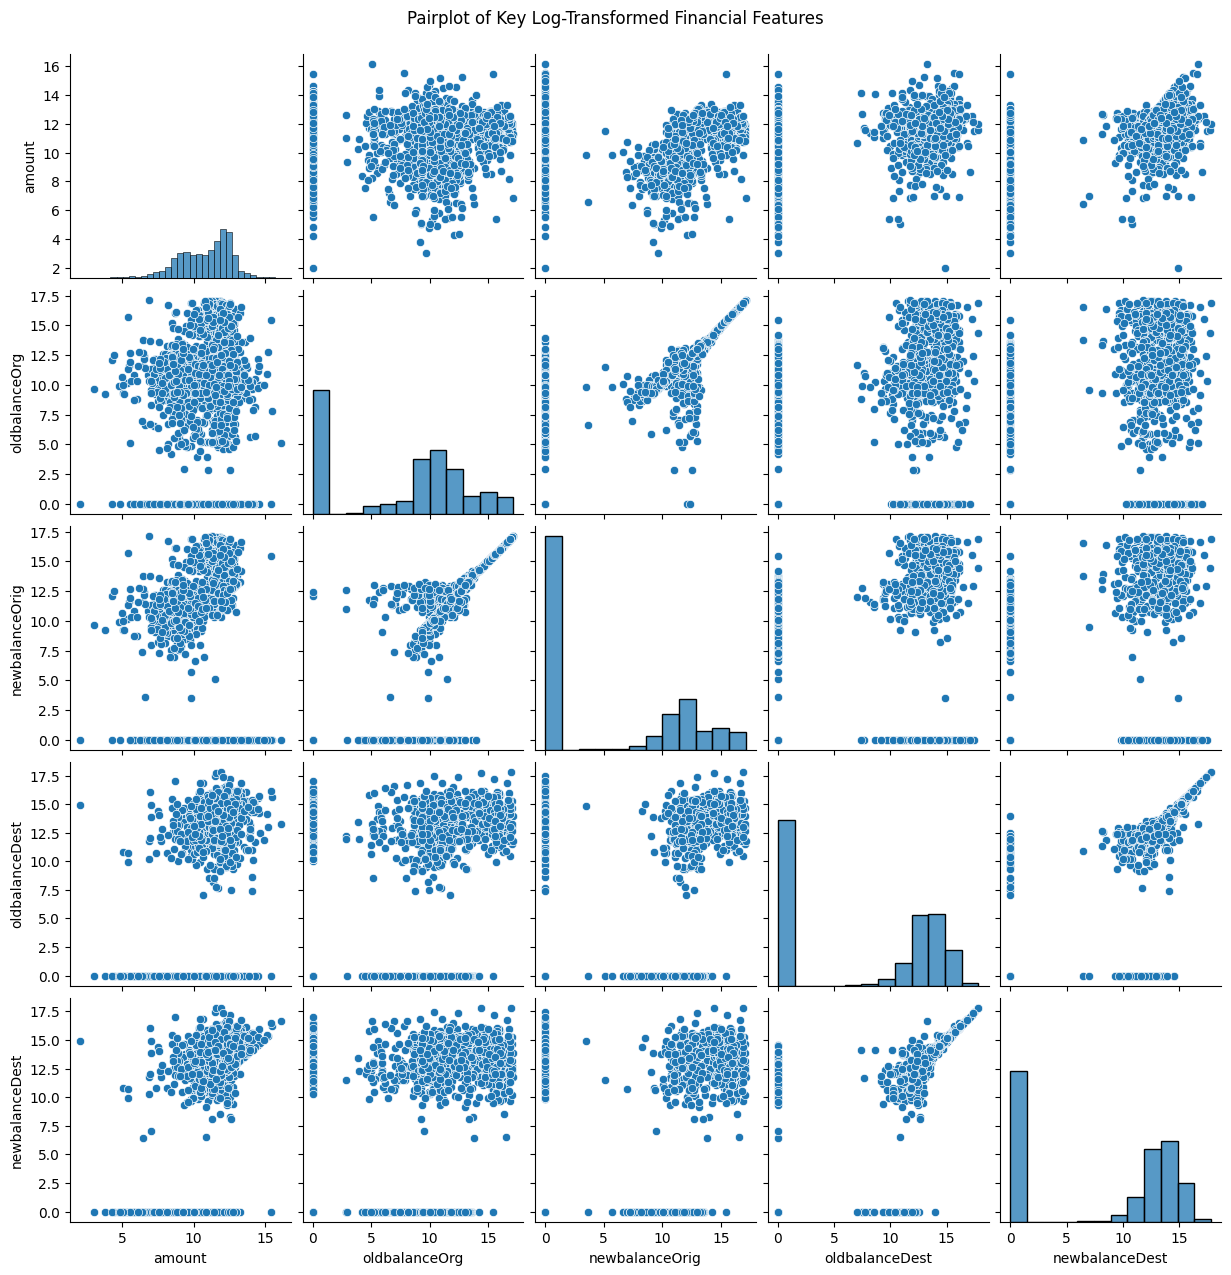

In [71]:
# Pairplot for key financial variables using a small sample for speed
pairplot_cols = [
    "amount", "oldbalanceOrg", "newbalanceOrig",
    "oldbalanceDest", "newbalanceDest"
]
pairplot_cols = [c for c in pairplot_cols if c in df_clean.columns]

pairplot_sample = df_plot[pairplot_cols].sample(
    n=min(2000, len(df_clean)),
    random_state=RANDOM_STATE
).copy()

for c in pairplot_cols:
    pairplot_sample[c] = np.log1p(pairplot_sample[c].clip(lower=0))

sns.pairplot(pairplot_sample, diag_kind="hist")
plt.suptitle("Pairplot of Key Log-Transformed Financial Features", y=1.02)
plt.show()

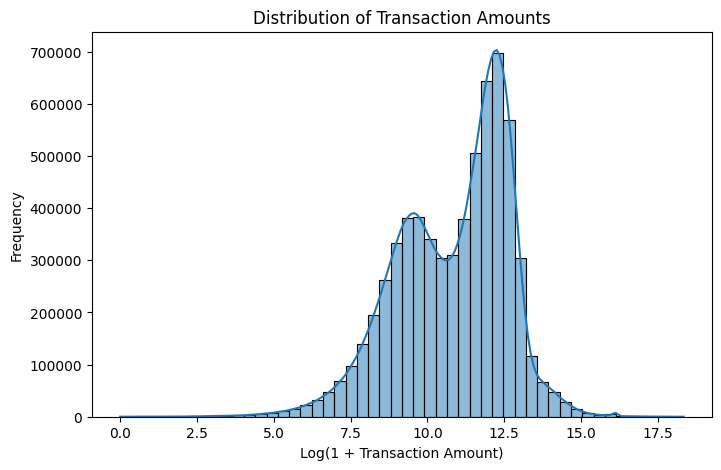

In [72]:
plt.figure(figsize=(8, 5))
sns.histplot(np.log1p(df_plot["amount"]), bins=50, kde=True)
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Log(1 + Transaction Amount)")
plt.ylabel("Frequency")
plt.show()

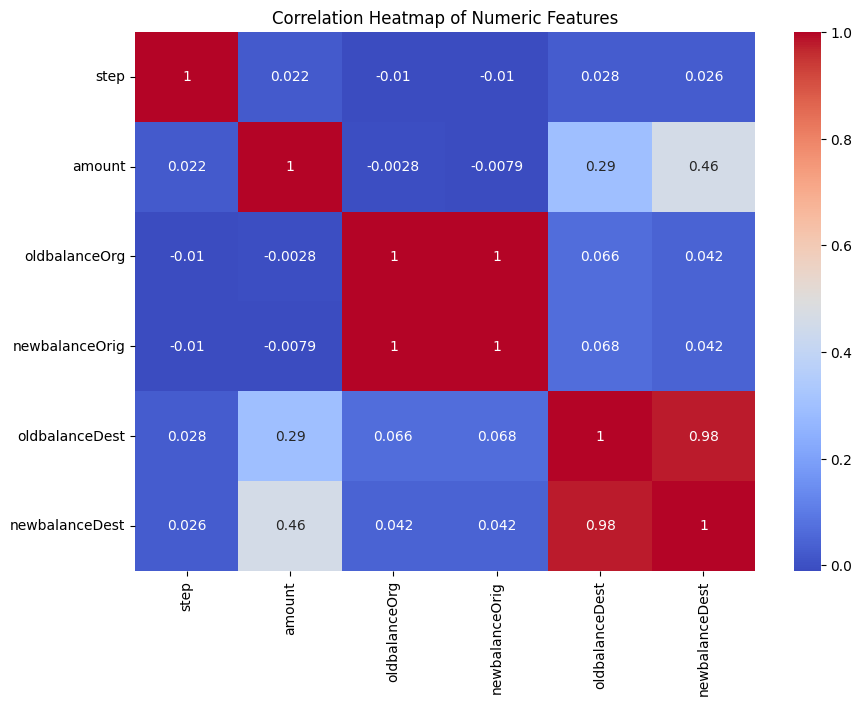

In [73]:
numeric_cols = df_plot.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(10, 7))
sns.heatmap(df_plot[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

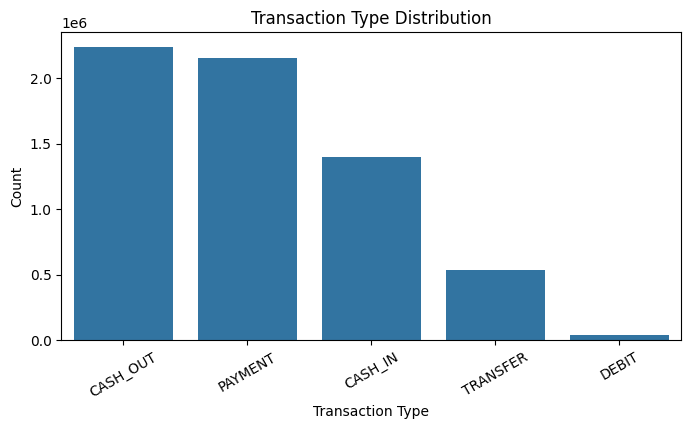

In [74]:
if "type" in df_plot.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df_plot, x="type", order=df_plot["type"].value_counts().index)
    plt.title("Transaction Type Distribution")
    plt.xlabel("Transaction Type")
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.show()

# 6. Feature Engineering

For a stronger project, the model should use customer-level behavior instead of only one transaction.

The following features are created:

- Number of transactions
- Average transaction amount
- Total transaction amount
- Maximum transaction amount
- Average old balance
- Average new balance
- Balance change
- Cash flow ratio
- Destination balance ratio
- Transaction type proportions, if transaction type exists

In [75]:
# If nameOrig exists, aggregate by customer. Otherwise, use each row as a customer.
if "nameOrig" in df_clean.columns:
    customer_id_col = "nameOrig"
else:
    customer_id_col = "customer_id"
    df_clean[customer_id_col] = cudf.Series(cp.arange(len(df_clean)))

# Balance change features
df_clean["origin_balance_change"] = df_clean["oldbalanceOrg"] - df_clean["newbalanceOrig"]
df_clean["dest_balance_change"] = df_clean["newbalanceDest"] - df_clean["oldbalanceDest"]

# Cash flow ratio - GPU friendly replacement for np.where
df_clean["cash_flow_ratio"] = 0.0
mask_origin = df_clean["oldbalanceOrg"] > 0
df_clean.loc[mask_origin, "cash_flow_ratio"] = (
    df_clean.loc[mask_origin, "amount"] / df_clean.loc[mask_origin, "oldbalanceOrg"]
)

# Destination balance ratio - GPU friendly replacement for np.where
df_clean["dest_balance_ratio"] = 0.0
mask_dest = df_clean["oldbalanceDest"] > 0
df_clean.loc[mask_dest, "dest_balance_ratio"] = (
    df_clean.loc[mask_dest, "amount"] / df_clean.loc[mask_dest, "oldbalanceDest"]
)

# Log features using CuPy/GPU
df_clean["log_amount"] = cp.log1p(df_clean["amount"].to_cupy())

cash_flow_clipped = df_clean["cash_flow_ratio"].clip(lower=0)
df_clean["log_cash_flow_ratio"] = cp.log1p(cash_flow_clipped.to_cupy())

agg_dict = {
    "amount": ["count", "mean", "sum", "max", "std"],
    "oldbalanceOrg": ["mean", "max"],
    "newbalanceOrig": ["mean", "max"],
    "oldbalanceDest": ["mean"],
    "newbalanceDest": ["mean"],
    "origin_balance_change": ["mean", "sum"],
    "dest_balance_change": ["mean"],
    "cash_flow_ratio": ["mean", "max"],
    "dest_balance_ratio": ["mean"],
    "log_amount": ["mean"],
    "log_cash_flow_ratio": ["mean"]
}

customer_df = df_clean.groupby(customer_id_col).agg(agg_dict)

customer_df.columns = [
    "_".join(col).strip() for col in customer_df.columns.to_flat_index()
]

customer_df = customer_df.reset_index()

customer_df = customer_df.rename(columns={
    "amount_count": "transaction_count",
    "amount_mean": "avg_transaction_amount",
    "amount_sum": "total_transaction_amount",
    "amount_max": "max_transaction_amount",
    "amount_std": "std_transaction_amount",
    "oldbalanceOrg_mean": "avg_oldbalance_org",
    "oldbalanceOrg_max": "max_oldbalance_org",
    "newbalanceOrig_mean": "avg_newbalance_orig",
    "newbalanceOrig_max": "max_newbalance_orig",
    "oldbalanceDest_mean": "avg_oldbalance_dest",
    "newbalanceDest_mean": "avg_newbalance_dest",
    "origin_balance_change_mean": "avg_origin_balance_change",
    "origin_balance_change_sum": "total_origin_balance_change",
    "dest_balance_change_mean": "avg_dest_balance_change",
    "cash_flow_ratio_mean": "avg_cash_flow_ratio",
    "cash_flow_ratio_max": "max_cash_flow_ratio",
    "dest_balance_ratio_mean": "avg_dest_balance_ratio",
    "log_amount_mean": "avg_log_amount",
    "log_cash_flow_ratio_mean": "avg_log_cash_flow_ratio"
})

# Transaction type proportions - GPU friendly replacement for pd.crosstab
if "type" in df_clean.columns:
    type_dummies = cudf.get_dummies(
        df_clean[[customer_id_col, "type"]],
        columns=["type"],
        prefix="type_ratio"
    )

    type_counts = type_dummies.groupby(customer_id_col).mean().reset_index()

    customer_df = customer_df.merge(
        type_counts,
        on=customer_id_col,
        how="left"
    )

customer_df = customer_df.fillna(0)

print("Customer-level dataset shape:", customer_df.shape)
customer_df.head()

Customer-level dataset shape: (6353307, 25)


,nameOrig,transaction_count,avg_transaction_amount,total_transaction_amount,max_transaction_amount,std_transaction_amount,avg_oldbalance_org,max_oldbalance_org,avg_newbalance_orig,max_newbalance_orig,...,avg_cash_flow_ratio,max_cash_flow_ratio,avg_dest_balance_ratio,avg_log_amount,avg_log_cash_flow_ratio,type_ratio_CASH_IN,type_ratio_CASH_OUT,type_ratio_DEBIT,type_ratio_PAYMENT,type_ratio_TRANSFER
0,C1503282347,1,284164.36,284164.36,284164.36,0.0,645587.0,645587.0,361422.64,361422.64,...,0.440164,0.440164,4.410689,12.557312,0.364757,0.0,1.0,0.0,0.0,0.0
1,C1024303614,1,156717.22,156717.22,156717.22,0.0,5006.0,5006.0,161723.22,161723.22,...,31.305877,31.305877,0.000000,11.962205,3.475249,1.0,0.0,0.0,0.0,0.0
2,C1306492090,1,24893.35,24893.35,24893.35,0.0,0.0,0.0,0.00,0.00,...,0.000000,0.000000,0.000000,10.122396,0.000000,0.0,0.0,0.0,1.0,0.0
3,C1472729815,1,20428.92,20428.92,20428.92,0.0,50133.0,50133.0,29704.08,29704.08,...,0.407494,0.407494,0.000000,9.924756,0.341811,0.0,0.0,0.0,1.0,0.0
4,C1302803199,1,30399.93,30399.93,30399.93,0.0,10825.0,10825.0,0.00,0.00,...,2.808308,2.808308,0.000000,10.322228,1.337185,0.0,0.0,0.0,1.0,0.0


# 7. Unsupervised Learning: Customer Clustering

This section uses GPU acceleration where it is useful and safe:

- **K-Means** is trained on the full customer dataset using **cuML/GPU**.
- **Gaussian Mixture Model** and **Agglomerative Clustering** are compared on a CPU sample because they are not fully supported by the current Kaggle/cuML setup.
- **PCA is used only for 2D visualization**, not for training the clusters.


Original customer_df size: (6353307, 25)
Cluster features used: ['transaction_count', 'avg_transaction_amount', 'total_transaction_amount', 'max_transaction_amount', 'std_transaction_amount', 'avg_oldbalance_org', 'avg_newbalance_orig', 'avg_origin_balance_change', 'avg_cash_flow_ratio', 'max_cash_flow_ratio', 'avg_log_amount', 'avg_log_cash_flow_ratio']


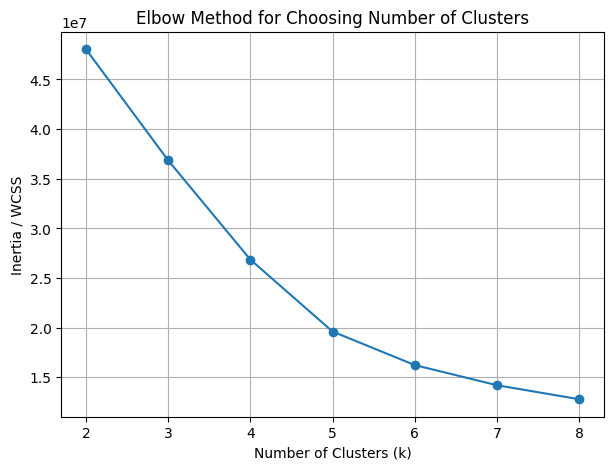

Unique cluster labels in metric sample: [0 1 2]


,Clustering Method,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score
2,Agglomerative Clustering (CPU sample),0.636594,3445.726584,0.649284
0,"K-Means (GPU, full data)",0.554480,3599.753264,1.129068
1,Gaussian Mixture Model (CPU sample),0.187052,1671.388719,1.880591


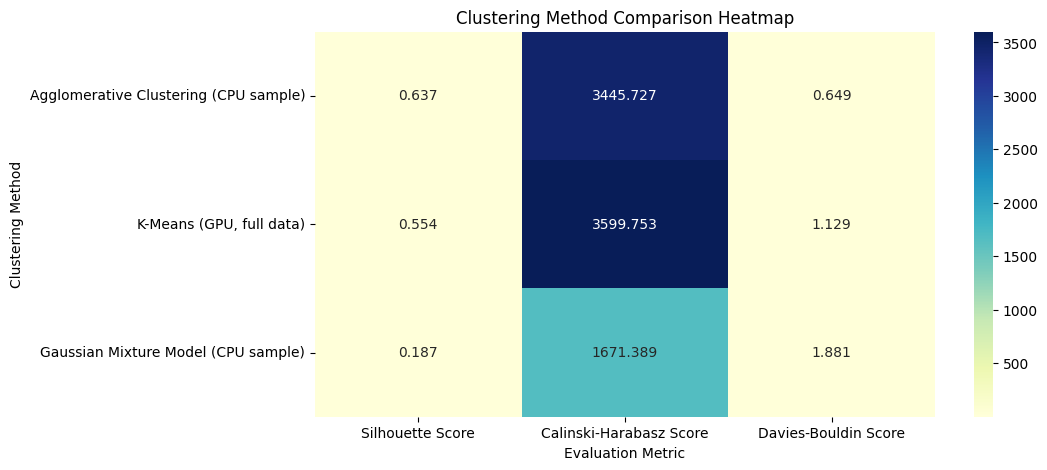

Best clustering method based on sample metrics: Agglomerative Clustering (CPU sample)

Note: The full customer_df uses K-Means cluster labels because K-Means was trained on the full GPU dataset.


,cluster,count
0,1,5509514
1,0,461416
2,2,382377


In [76]:
# GPU + CPU-safe clustering comparison and visualisation

cluster_features = [
    "transaction_count",
    "avg_transaction_amount",
    "total_transaction_amount",
    "max_transaction_amount",
    "std_transaction_amount",
    "avg_oldbalance_org",
    "avg_newbalance_orig",
    "avg_origin_balance_change",
    "avg_cash_flow_ratio",
    "max_cash_flow_ratio",
    "avg_log_amount",
    "avg_log_cash_flow_ratio"
]

cluster_features = [c for c in cluster_features if c in customer_df.columns]

print("Original customer_df size:", customer_df.shape)
print("Cluster features used:", cluster_features)

# Keep the main feature matrix on GPU
X_cluster = customer_df[cluster_features]
X_cluster = X_cluster.replace([np.inf, -np.inf], np.nan).fillna(0)

# Clip extreme outliers to 99th percentile before scaling
# This prevents a tiny number of extreme rows from collapsing all other points into one cluster
for col in cluster_features:
    upper = float(X_cluster[col].quantile(0.99))
    lower = float(X_cluster[col].quantile(0.01))
    X_cluster[col] = X_cluster[col].clip(lower=lower, upper=upper)

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# ---------------------------------------------------------
# 1. Elbow Method for GPU K-Means
# ---------------------------------------------------------
inertias = []
k_values = range(2, 9)

for k in k_values:
    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10,
        max_iter=300
    )
    km.fit(X_cluster_scaled)
    inertias.append(float(km.inertia_))

plt.figure(figsize=(7, 5))
plt.plot(list(k_values), inertias, marker="o")
plt.title("Elbow Method for Choosing Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia / WCSS")
plt.grid(True)
plt.show()

# For loan risk interpretation, use 3 clusters: Low, Medium, and High Risk
N_CLUSTERS = 3

# ---------------------------------------------------------
# 2. K-Means on full dataset using GPU
# ---------------------------------------------------------
kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=10,
    max_iter=300
)

kmeans_labels = kmeans.fit_predict(X_cluster_scaled)

# Assign K-Means labels to the full customer dataframe
customer_df["cluster"] = kmeans_labels

# ---------------------------------------------------------
# 3. Prepare CPU sample for metrics and method comparison
# ---------------------------------------------------------
sample_size = min(10000, len(customer_df))

# Convert only a sample to CPU for sklearn metrics and CPU-only algorithms
X_metric = X_cluster_scaled[:sample_size].to_numpy()
kmeans_labels_metric = kmeans_labels[:sample_size].to_numpy()

# Safety check: if the sample only has 1 unique label, expand the sample
# This can happen if the first N rows all belong to the same cluster
unique_labels = np.unique(kmeans_labels_metric)
if len(unique_labels) < 2:
    print("WARNING: Sample had only 1 cluster label. Re-sampling randomly across full dataset.")
    all_labels_np = kmeans_labels.to_numpy()
    all_X_np = X_cluster_scaled.to_numpy()
    rng = np.random.default_rng(RANDOM_STATE)
    idx = rng.choice(len(all_labels_np), size=sample_size, replace=False)
    X_metric = all_X_np[idx]
    kmeans_labels_metric = all_labels_np[idx]
    unique_labels = np.unique(kmeans_labels_metric)
    print(f"After re-sampling, unique cluster labels in sample: {unique_labels}")

print(f"Unique cluster labels in metric sample: {unique_labels}")

# ---------------------------------------------------------
# 4. Compare clustering methods
# ---------------------------------------------------------
clustering_results = []

def add_clustering_result(method_name, labels):
    u = np.unique(labels)
    if len(u) < 2:
        print(f"Skipping metrics for '{method_name}': only {len(u)} unique label(s) in sample.")
        clustering_results.append({
            "Clustering Method": method_name,
            "Silhouette Score": float("nan"),
            "Calinski-Harabasz Score": float("nan"),
            "Davies-Bouldin Score": float("nan")
        })
        return
    clustering_results.append({
        "Clustering Method": method_name,
        "Silhouette Score": silhouette_score(X_metric, labels),
        "Calinski-Harabasz Score": calinski_harabasz_score(X_metric, labels),
        "Davies-Bouldin Score": davies_bouldin_score(X_metric, labels)
    })

# K-Means metric on the sample
add_clustering_result("K-Means (GPU, full data)", kmeans_labels_metric)

# Gaussian Mixture Model on CPU sample
gmm = GaussianMixture(
    n_components=N_CLUSTERS,
    random_state=RANDOM_STATE,
    covariance_type="full"
)
gmm_labels_metric = gmm.fit_predict(X_metric)
add_clustering_result("Gaussian Mixture Model (CPU sample)", gmm_labels_metric)

# Agglomerative Clustering on CPU sample
agg = AgglomerativeClustering(n_clusters=N_CLUSTERS)
agg_labels_metric = agg.fit_predict(X_metric)
add_clustering_result("Agglomerative Clustering (CPU sample)", agg_labels_metric)

clustering_results_df = pd.DataFrame(clustering_results)

clustering_results_df = clustering_results_df.sort_values(
    by=["Silhouette Score", "Davies-Bouldin Score"],
    ascending=[False, True]
)

display(clustering_results_df)

# Metric comparison heatmap
cluster_metric_df = clustering_results_df.set_index("Clustering Method")

plt.figure(figsize=(10, 5))
sns.heatmap(cluster_metric_df, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Clustering Method Comparison Heatmap")
plt.xlabel("Evaluation Metric")
plt.ylabel("Clustering Method")
plt.show()

best_cluster_method = clustering_results_df.iloc[0]["Clustering Method"]
print("Best clustering method based on sample metrics:", best_cluster_method)

print("\nNote: The full customer_df uses K-Means cluster labels because K-Means was trained on the full GPU dataset.")
display(customer_df["cluster"].value_counts().reset_index(name="count"))


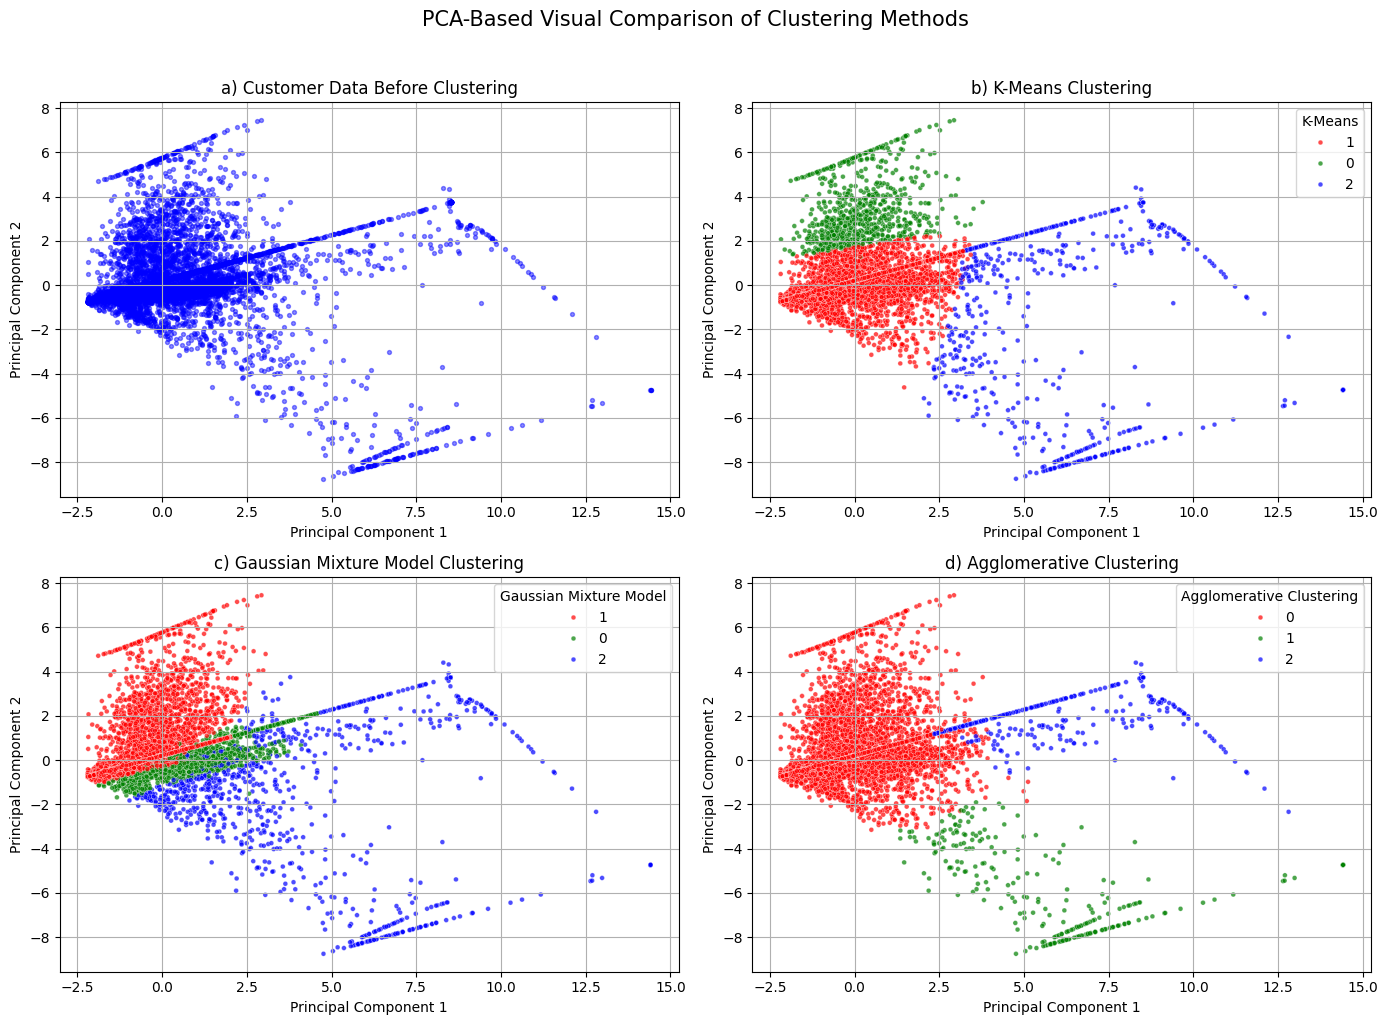

In [83]:
# 2D PCA visualisation: before clustering and after each clustering method

# GPU PCA for K-Means/full-data sample visualisation
pca = cuPCA(n_components=2)
X_pca_gpu = pca.fit_transform(X_cluster_scaled[:sample_size])
X_pca = X_pca_gpu.to_numpy()

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "K-Means": kmeans_labels_metric.astype(str),
    "Gaussian Mixture Model": gmm_labels_metric.astype(str),
    "Agglomerative Clustering": agg_labels_metric.astype(str)
})

plt.figure(figsize=(14, 10))

# a) Before clustering
plt.subplot(2, 2, 1)
plt.scatter(pca_df["PC1"], pca_df["PC2"], s=8, alpha=0.45, color="blue")
plt.title("a) Customer Data Before Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)

# b) K-Means
plt.subplot(2, 2, 2)
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="K-Means",
    palette=["red", "green", "blue"],
    s=12,
    alpha=0.7,
    legend=True
)
plt.title("b) K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)

# c) Gaussian Mixture Model
plt.subplot(2, 2, 3)
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Gaussian Mixture Model",
    palette=["red", "green", "blue"],
    s=12,
    alpha=0.7,
    legend=True
)
plt.title("c) Gaussian Mixture Model Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)

# d) Agglomerative Clustering
plt.subplot(2, 2, 4)
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Agglomerative Clustering",
    palette=["red", "green", "blue"],
    s=12,
    alpha=0.7,
    legend=True
)
plt.title("d) Agglomerative Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)

plt.suptitle("PCA-Based Visual Comparison of Clustering Methods", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


# 8. Cluster Profiling and Risk Interpretation

The K-Means clusters are profiled using average transaction behaviour. The cluster with the highest transaction pressure and cash-flow pressure is interpreted as the highest risk group.


,transaction_count,avg_transaction_amount,total_transaction_amount,max_transaction_amount,std_transaction_amount,avg_oldbalance_org,avg_newbalance_orig,avg_origin_balance_change,avg_cash_flow_ratio,max_cash_flow_ratio,avg_log_amount,avg_log_cash_flow_ratio
cluster,,,,,,,,,,,,
0,1.001218,1.853039e+05,1.855048e+05,1.854110e+05,151.365019,9.283080e+06,9.468180e+06,-185099.609451,0.039767,0.046730,11.762300,0.031871
1,1.001422,1.097899e+05,1.099538e+05,1.098908e+05,142.525522,1.800126e+05,1.900219e+05,-10009.228702,6.967053,6.978527,10.587390,0.747323
2,1.002393,1.182854e+06,1.184711e+06,1.184390e+06,2170.699081,6.000181e+04,4.518378e+04,14818.022778,1257.199341,1259.037429,13.381581,3.978150


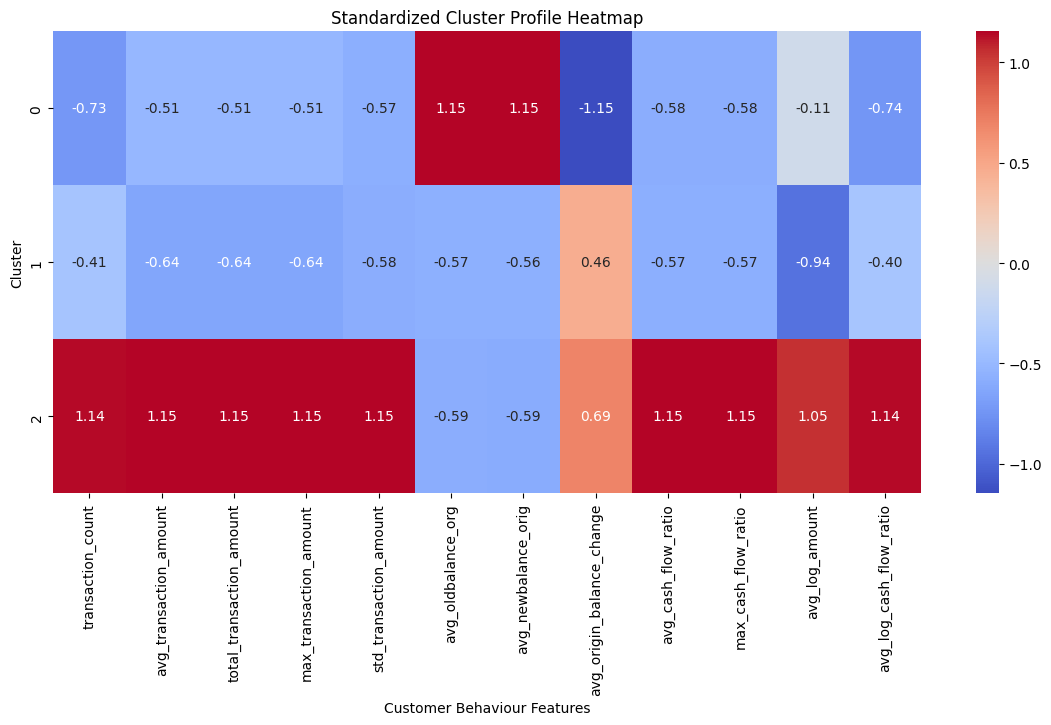

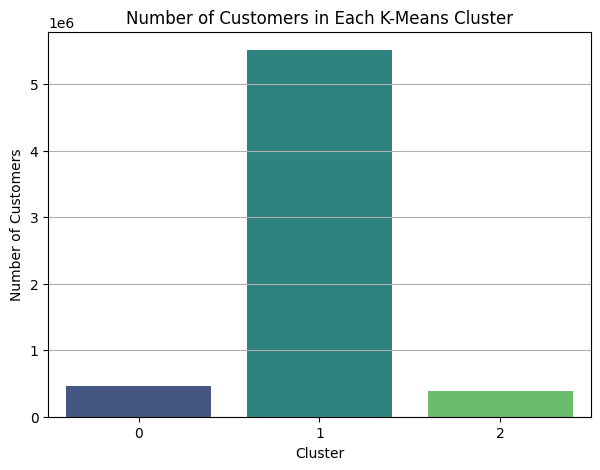

Cluster risk mapping:
{0: 'Low Risk', 1: 'Medium Risk', 2: 'High Risk'}


,nameOrig,cluster,risk_group
0,C1503282347,1,Medium Risk
1,C1024303614,1,Medium Risk
2,C1306492090,1,Medium Risk
3,C1472729815,1,Medium Risk
4,C1302803199,1,Medium Risk


risk_group
Medium Risk    5509514
Low Risk        461416
High Risk       382377
Name: count, dtype: int64

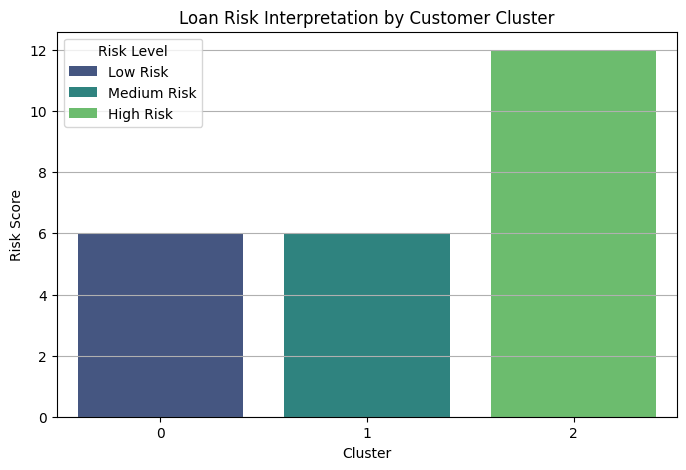

In [78]:
# Cluster profile and risk interpretation

customer_pd = customer_df.to_pandas() if hasattr(customer_df, "to_pandas") else customer_df.copy()

cluster_profile = customer_pd.groupby("cluster")[cluster_features].mean()
display(cluster_profile)

# Standardized cluster profile heatmap
cluster_profile_scaled = (
    cluster_profile - cluster_profile.mean()
) / cluster_profile.std()

plt.figure(figsize=(14, 6))
sns.heatmap(
    cluster_profile_scaled,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Standardized Cluster Profile Heatmap")
plt.xlabel("Customer Behaviour Features")
plt.ylabel("Cluster")
plt.show()

# Cluster size graph
cluster_counts = customer_pd["cluster"].value_counts().reset_index()
cluster_counts.columns = ["Cluster", "Number of Customers"]

plt.figure(figsize=(7, 5))
sns.barplot(
    data=cluster_counts,
    x="Cluster",
    y="Number of Customers",
    palette="viridis"
)
plt.title("Number of Customers in Each K-Means Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.grid(axis="y")
plt.show()

# Risk scoring
risk_profile = cluster_profile.copy()

risk_profile["cluster_risk_score"] = (
    risk_profile["avg_cash_flow_ratio"].rank() +
    risk_profile["max_cash_flow_ratio"].rank() +
    risk_profile["avg_transaction_amount"].rank() +
    risk_profile["total_transaction_amount"].rank()
)

risk_order = risk_profile["cluster_risk_score"].sort_values().index.tolist()
risk_names = ["Low Risk", "Medium Risk", "High Risk"]
risk_mapping = {cluster_id: risk_name for cluster_id, risk_name in zip(risk_order, risk_names)}

print("Cluster risk mapping:")
print(risk_mapping)

# Add risk group to both pandas view and GPU dataframe
customer_pd["risk_group"] = customer_pd["cluster"].map(risk_mapping)

try:
    customer_df["risk_group"] = customer_df["cluster"].map(risk_mapping)
except Exception:
    # Fallback if cuDF map with dictionary fails
    customer_df = customer_pd.copy()

display(customer_pd[[customer_id_col, "cluster", "risk_group"]].head())
display(customer_pd["risk_group"].value_counts())

# Risk score graph
risk_plot_df = risk_profile.reset_index()
risk_plot_df["Risk Level"] = risk_plot_df["cluster"].map(risk_mapping)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=risk_plot_df,
    x="cluster",
    y="cluster_risk_score",
    hue="Risk Level",
    palette="viridis"
)
plt.title("Loan Risk Interpretation by Customer Cluster")
plt.xlabel("Cluster")
plt.ylabel("Risk Score")
plt.grid(axis="y")
plt.show()


## Clustering Interpretation

The first PCA plot shows the customer behaviour space before clustering. The following plots show how K-Means, Gaussian Mixture Model, and Agglomerative Clustering separate customers into three risk-based groups. The PCA axes are only used for visualisation; the clustering models use the full customer-level feature set.

K-Means is used for the full dataset because it runs efficiently on the GPU through cuML. Gaussian Mixture Model and Agglomerative Clustering are included for academic comparison on a sample, since they rely on CPU-based scikit-learn in this Kaggle environment.


# 9. Create Supervised Learning Targets

## 9.1 Loan Eligibility Target

If real loan labels are not available, we create a transparent academic target.

A customer is considered eligible when they show:

- Positive balance or transaction capacity
- Reasonable cash-flow pressure
- Not in the high-risk cluster
- Transaction behavior above a minimum activity threshold

## 9.2 Loan Amount Target

The eligible loan amount is estimated using financial behavior and capped to avoid unrealistic values.

For a Uganda mobile money context, we use a small starting amount and a maximum academic cap.

In [79]:
# Adaptive thresholds make the notebook work even when many customers have only one transaction.
transaction_threshold = max(1, int(customer_df["transaction_count"].quantile(0.25)))
balance_threshold = customer_df["avg_oldbalance_org"].quantile(0.25)
cash_flow_threshold = customer_df["avg_cash_flow_ratio"].replace([np.inf, -np.inf], np.nan).fillna(0).quantile(0.75)

print("Transaction threshold:", transaction_threshold)
print("Balance threshold:", balance_threshold)
print("Cash-flow threshold:", cash_flow_threshold)

customer_df["is_eligible"] = (
    (customer_df["transaction_count"] >= transaction_threshold) &
    (customer_df["avg_oldbalance_org"] >= balance_threshold) &
    (customer_df["avg_cash_flow_ratio"] <= cash_flow_threshold) &
    (customer_df["risk_group"] != "High Risk")
).astype(int)

# If one class is missing, relax the condition slightly to avoid model failure.
if int(int(customer_df["is_eligible"].nunique())) < 2:
    customer_df["is_eligible"] = (
        (customer_df["avg_oldbalance_org"] >= customer_df["avg_oldbalance_org"].median()) &
        (customer_df["risk_group"] != "High Risk")
    ).astype(int)

if int(int(customer_df["is_eligible"].nunique())) < 2:
    customer_df["is_eligible"] = (
        customer_df["avg_oldbalance_org"] >= customer_df["avg_oldbalance_org"].median()
    ).astype(int)

print(customer_df["is_eligible"].value_counts())
customer_df[[customer_id_col, "risk_group", "is_eligible"]].head()

Transaction threshold: 1
Balance threshold: 0.0
Cash-flow threshold: 2.2242936611163056
is_eligible
1    4656859
0    1696448
Name: count, dtype: int64


,nameOrig,risk_group,is_eligible
0,C1503282347,Medium Risk,1
1,C1024303614,Medium Risk,0
2,C1306492090,Medium Risk,1
3,C1472729815,Medium Risk,1
4,C1302803199,Medium Risk,0


In [84]:
customer_df = customer_df.to_pandas() if hasattr(customer_df, "to_pandas") else customer_df

model_df = customer_df.copy()
# Loan amount target.
# Starting amount is set at UGX 2,000 for eligible customers.
# The upper cap is UGX 500,000 for academic demonstration.
START_AMOUNT = 2000
MAX_LOAN_AMOUNT = 500000

capacity_component = 0.15 * customer_df["avg_oldbalance_org"]
activity_component = 0.05 * customer_df["total_transaction_amount"]
stability_component = 0.10 * customer_df["avg_newbalance_orig"]

raw_loan_amount = START_AMOUNT + capacity_component + activity_component + stability_component

# Penalize by risk group.
risk_multiplier = customer_df["risk_group"].map({
    "Low Risk": 1.00,
    "Medium Risk": 0.65,
    "High Risk": 0.00
}).fillna(0.50)

customer_df["eligible_loan_amount"] = np.where(
    customer_df["is_eligible"] == 1,
    raw_loan_amount * risk_multiplier,
    0
)

customer_df["eligible_loan_amount"] = customer_df["eligible_loan_amount"].clip(
    lower=0,
    upper=MAX_LOAN_AMOUNT
).round(0)

customer_df[[customer_id_col, "risk_group", "is_eligible", "eligible_loan_amount"]].head()

,nameOrig,risk_group,is_eligible,eligible_loan_amount
0,C1503282347,Medium Risk,1,96973.0
1,C1024303614,Medium Risk,0,0.0
2,C1306492090,Medium Risk,1,2109.0
3,C1472729815,Medium Risk,1,8783.0
4,C1302803199,Medium Risk,0,0.0


# 10. Prepare Data for Supervised Learning

We include the cluster and risk group as model features because they summarize customer behavior from unsupervised learning.

In [85]:
# Convert customer_df to pandas before supervised learning
customer_df = customer_df.to_pandas() if hasattr(customer_df, "to_pandas") else customer_df

model_df = customer_df.copy()

# Encode risk group manually.
risk_group_map_numeric = {
    "Low Risk": 0,
    "Medium Risk": 1,
    "High Risk": 2
}

model_df["risk_group_encoded"] = model_df["risk_group"].map(risk_group_map_numeric).fillna(1)

supervised_features = [
    "transaction_count",
    "avg_transaction_amount",
    "total_transaction_amount",
    "max_transaction_amount",
    "std_transaction_amount",
    "avg_oldbalance_org",
    "max_oldbalance_org",
    "avg_newbalance_orig",
    "max_newbalance_orig",
    "avg_oldbalance_dest",
    "avg_newbalance_dest",
    "avg_origin_balance_change",
    "total_origin_balance_change",
    "avg_dest_balance_change",
    "avg_cash_flow_ratio",
    "max_cash_flow_ratio",
    "avg_dest_balance_ratio",
    "avg_log_amount",
    "avg_log_cash_flow_ratio",
    "cluster",
    "risk_group_encoded"
]

# Add transaction type ratio columns if available.
type_ratio_cols = [c for c in model_df.columns if c.startswith("type_ratio_")]
supervised_features += type_ratio_cols

supervised_features = [c for c in supervised_features if c in model_df.columns]

X = model_df[supervised_features].replace([np.inf, -np.inf], np.nan).fillna(0)
y_class = model_df["is_eligible"]

print("Number of supervised features:", len(supervised_features))
print(supervised_features)
print("\nClass distribution:")
print(y_class.value_counts())

Number of supervised features: 26
['transaction_count', 'avg_transaction_amount', 'total_transaction_amount', 'max_transaction_amount', 'std_transaction_amount', 'avg_oldbalance_org', 'max_oldbalance_org', 'avg_newbalance_orig', 'max_newbalance_orig', 'avg_oldbalance_dest', 'avg_newbalance_dest', 'avg_origin_balance_change', 'total_origin_balance_change', 'avg_dest_balance_change', 'avg_cash_flow_ratio', 'max_cash_flow_ratio', 'avg_dest_balance_ratio', 'avg_log_amount', 'avg_log_cash_flow_ratio', 'cluster', 'risk_group_encoded', 'type_ratio_CASH_IN', 'type_ratio_CASH_OUT', 'type_ratio_DEBIT', 'type_ratio_PAYMENT', 'type_ratio_TRANSFER']

Class distribution:
is_eligible
1    4656859
0    1696448
Name: count, dtype: int64


# 11. Supervised Learning: Loan Eligibility Classification

Six classification models are trained and compared using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

For loan eligibility, **precision and F1 score are very important** because approving risky customers can lead to financial loss.

In [ ]:
print("Rows going into supervised learning:", len(model_df))

In [ ]:
print("Rows going into supervised learning:", len(model_df))
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_class if y_class.nunique() == 2 else None
)

# Convert to pandas for sklearn model compatibility
X_train_pd = X_train.to_pandas() if hasattr(X_train, "to_pandas") else X_train.copy()
X_test_pd  = X_test.to_pandas()  if hasattr(X_test,  "to_pandas") else X_test.copy()
y_train_pd = y_train.to_pandas() if hasattr(y_train, "to_pandas") else y_train.copy()
y_test_pd  = y_test.to_pandas()  if hasattr(y_test,  "to_pandas") else y_test.copy()

from sklearn.preprocessing import StandardScaler as SKScaler
from sklearn.linear_model import LogisticRegression as SKLogReg

classification_models = {
    "Logistic Regression": Pipeline([
        ("scaler", SKScaler()),
        ("model", SKLogReg(max_iter=1000, random_state=RANDOM_STATE))
    ]),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE, n_estimators=100),
    "Support Vector Machine": Pipeline([
        ("scaler", SKScaler()),
        ("model", SVC(probability=True, random_state=RANDOM_STATE))
    ]),
    "K-Nearest Neighbors": Pipeline([
        ("scaler", SKScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ])
}

classification_results = []

for name, model in classification_models.items():
    model.fit(X_train_pd, y_train_pd)
    y_pred = model.predict(X_test_pd)

    y_prob = model.predict_proba(X_test_pd)[:, 1] if hasattr(model, "predict_proba") else None

    auc_score = (
        roc_auc_score(y_test_pd, y_prob)
        if y_prob is not None and len(set(y_test_pd)) == 2
        else float("nan")
    )

    classification_results.append({
        "Model":     name,
        "Accuracy":  accuracy_score(y_test_pd, y_pred),
        "Precision": precision_score(y_test_pd, y_pred, zero_division=0),
        "Recall":    recall_score(y_test_pd, y_pred, zero_division=0),
        "F1 Score":  f1_score(y_test_pd, y_pred, zero_division=0),
        "ROC-AUC":   auc_score
    })

classification_results_df = pd.DataFrame(classification_results)
classification_results_df.sort_values(by=["F1 Score", "Precision", "ROC-AUC"], ascending=False)


# Classification Model Comparison Graphs

These graphs compare all loan eligibility models using class metrics such as accuracy, precision, recall, F1-score, and ROC-AUC.

In [ ]:
classification_metric_cols = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
classification_heatmap_df = classification_results_df.set_index("Model")[classification_metric_cols]

plt.figure(figsize=(10, 6))
sns.heatmap(classification_heatmap_df, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Classification Model Performance Heatmap")
plt.xlabel("Evaluation Metric")
plt.ylabel("Model")
plt.show()

In [ ]:
classification_results_long = classification_results_df.melt(
    id_vars="Model",
    value_vars=classification_metric_cols,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=classification_results_long, x="Model", y="Score", hue="Metric")
plt.title("Classification Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
# ROC curves for all models
plt.figure(figsize=(8, 6))

for name, model in classification_models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_pd)[:, 1]
        fpr, tpr, _ = roc_curve(y_test_pd, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guessing")
plt.title("ROC Curves for Loan Eligibility Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
# Confusion matrices for all classification models
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for ax, (name, model) in zip(axes, classification_models.items()):
    y_pred_model = model.predict(X_test_pd)
    cm = confusion_matrix(y_test_pd, y_pred_model)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices for All Classification Models", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
best_classification_row = classification_results_df.sort_values(
    by=["F1 Score", "Precision", "ROC-AUC"],
    ascending=False
).iloc[0]

best_classification_model_name = best_classification_row["Model"]
best_classification_model = classification_models[best_classification_model_name]

print("Best loan eligibility model:", best_classification_model_name)
display(best_classification_row.to_frame().T)

y_pred_best = best_classification_model.predict(X_test_pd)

print("\nClassification Report:")
print(classification_report(y_test_pd, y_pred_best, zero_division=0))

cm = confusion_matrix(y_test_pd, y_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix: {best_classification_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Cross-Validation for Generalization

Cross-validation checks whether the selected classification model performs consistently across different splits of the dataset.

In [ ]:
# Convert full feature matrix to pandas for cross-validation
X_pd      = X.to_pandas() if hasattr(X, "to_pandas") else X.copy()
y_class_pd = y_class.to_pandas() if hasattr(y_class, "to_pandas") else y_class.copy()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = []

for name, model in classification_models.items():
    scores = cross_val_score(model, X_pd, y_class_pd, cv=cv, scoring="f1")
    cv_results.append({
        "Model": name,
        "Mean CV F1": scores.mean(),
        "Std CV F1":  scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("Mean CV F1", ascending=False)
display(cv_results_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=cv_results_df, x="Model", y="Mean CV F1")
plt.errorbar(
    x=np.arange(len(cv_results_df)),
    y=cv_results_df["Mean CV F1"],
    yerr=cv_results_df["Std CV F1"],
    fmt="none",
    capsize=5
)
plt.title("5-Fold Cross-Validation F1 Score by Classification Model")
plt.xlabel("Model")
plt.ylabel("Mean F1 Score")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


# 12. Supervised Learning: Loan Amount Regression

Only eligible customers are used for loan amount prediction because ineligible customers receive UGX 0.

Six regression models are compared using:

- MAE: Mean Absolute Error
- RMSE: Root Mean Squared Error
- R² Score

For loan amount prediction, the best model should have the **lowest RMSE and MAE** and the **highest R² Score**.

In [ ]:
eligible_model_df = model_df[model_df["is_eligible"] == 1].copy()
eligible_model_df = eligible_model_df.to_pandas() if hasattr(eligible_model_df, "to_pandas") else eligible_model_df

if len(eligible_model_df) < 10:
    print("Warning: Few eligible customers. Regression results may not be reliable.")

from sklearn.preprocessing import StandardScaler as SKScaler2
from sklearn.linear_model import LinearRegression as SKLinReg, Ridge as SKRidge
from sklearn.neighbors import KNeighborsRegressor as SKKNNReg

X_reg = eligible_model_df[supervised_features].replace([np.inf, -np.inf], np.nan).fillna(0)
y_reg = eligible_model_df["eligible_loan_amount"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg,
    test_size=0.30,
    random_state=RANDOM_STATE
)

# Convert to pandas/numpy for sklearn
X_train_reg = X_train_reg.to_pandas() if hasattr(X_train_reg, "to_pandas") else X_train_reg
X_test_reg  = X_test_reg.to_pandas()  if hasattr(X_test_reg,  "to_pandas") else X_test_reg
y_train_reg = y_train_reg.to_pandas() if hasattr(y_train_reg, "to_pandas") else y_train_reg
y_test_reg  = y_test_reg.to_pandas()  if hasattr(y_test_reg,  "to_pandas") else y_test_reg

regression_models = {
    "Linear Regression": Pipeline([
        ("scaler", SKScaler2()),
        ("model",  SKLinReg())
    ]),
    "Ridge Regression": Pipeline([
        ("scaler", SKScaler2()),
        ("model",  SKRidge(alpha=1.0))
    ]),
    "Decision Tree Regressor":    DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE),
    "Random Forest Regressor":    RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=100),
    "KNN Regressor": Pipeline([
        ("scaler", SKScaler2()),
        ("model",  KNeighborsRegressor(n_neighbors=5))
    ])
}

regression_results = []

for name, model in regression_models.items():
    model.fit(X_train_reg, y_train_reg)
    y_pred_reg = model.predict(X_test_reg)

    mae  = mean_absolute_error(y_test_reg, y_pred_reg)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
    r2   = r2_score(y_test_reg, y_pred_reg)

    regression_results.append({
        "Model":    name,
        "MAE":      mae,
        "RMSE":     rmse,
        "R2 Score": r2
    })

regression_results_df = pd.DataFrame(regression_results)
regression_results_df.sort_values(by=["RMSE", "MAE"], ascending=True)


# Regression Model Comparison Graphs

These graphs compare models for eligible loan amount prediction using MAE, RMSE, and R².

In [ ]:
regression_metric_cols = ["MAE", "RMSE", "R2 Score"]
regression_heatmap_df = regression_results_df.set_index("Model")[regression_metric_cols]

plt.figure(figsize=(10, 6))
sns.heatmap(regression_heatmap_df, annot=True, fmt=".3f", cmap="YlOrRd")
plt.title("Regression Model Performance Heatmap")
plt.xlabel("Evaluation Metric")
plt.ylabel("Model")
plt.show()

In [ ]:
plt.figure(figsize=(10, 5))
rmse_sorted = regression_results_df.sort_values("RMSE")
sns.barplot(data=rmse_sorted, x="Model", y="RMSE")
plt.title("Regression Models Ranked by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
best_regression_row = regression_results_df.sort_values(
    by=["RMSE", "MAE"],
    ascending=True
).iloc[0]

best_regression_model_name = best_regression_row["Model"]
best_regression_model = regression_models[best_regression_model_name]

print("Best loan amount prediction model:", best_regression_model_name)
display(best_regression_row.to_frame().T)

y_pred_reg_best = best_regression_model.predict(X_test_reg)

plt.figure(figsize=(6, 5))
sns.scatterplot(x=y_test_reg, y=y_pred_reg_best)
plt.title(f"Actual vs Predicted Loan Amount: {best_regression_model_name}")
plt.xlabel("Actual Loan Amount")
plt.ylabel("Predicted Loan Amount")
plt.show()

In [ ]:
# Actual vs predicted and residual plot for the best regression model
y_pred_reg_best = best_regression_model.predict(X_test_reg)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test_reg, y=y_pred_reg_best, alpha=0.7)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], linestyle="--")
plt.title(f"Actual vs Predicted Loan Amount: {best_regression_model_name}")
plt.xlabel("Actual Loan Amount")
plt.ylabel("Predicted Loan Amount")
plt.show()

residuals = y_test_reg - y_pred_reg_best

plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_pred_reg_best, y=residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.title(f"Residual Plot: {best_regression_model_name}")
plt.xlabel("Predicted Loan Amount")
plt.ylabel("Residuals")
plt.show()

# 13. Feature Importance

Tree-based models can show which features influence loan eligibility or loan amount prediction most.

This helps explain the model, which is important at master level.

In [ ]:
def plot_feature_importance(model, feature_names, title):
    if hasattr(model, "feature_importances_"):
        importance_df = pd.DataFrame({
            "Feature": feature_names,
            "Importance": model.feature_importances_
        }).sort_values(by="Importance", ascending=False).head(15)

        plt.figure(figsize=(8, 6))
        sns.barplot(data=importance_df, x="Importance", y="Feature")
        plt.title(title)
        plt.show()

        return importance_df
    else:
        print("This model does not provide direct feature importance.")
        return None

print("Classification feature importance:")
classification_importance = plot_feature_importance(
    best_classification_model,
    supervised_features,
    f"Top Features for {best_classification_model_name}"
)

if classification_importance is not None:
    display(classification_importance)

print("\nRegression feature importance:")
regression_importance = plot_feature_importance(
    best_regression_model,
    supervised_features,
    f"Top Features for {best_regression_model_name}"
)

if regression_importance is not None:
    display(regression_importance)

# 14. Final Prediction Function

This function gives a final loan decision for a customer already in the processed customer dataset.

In [ ]:
def predict_customer_loan(customer_index):
    customer_row = model_df.iloc[[customer_index]]
    customer_features = customer_row[supervised_features].replace([np.inf, -np.inf], np.nan).fillna(0)

    eligibility_prediction = best_classification_model.predict(customer_features)[0]

    if hasattr(best_classification_model, "predict_proba"):
        eligibility_probability = best_classification_model.predict_proba(customer_features)[0][1]
    else:
        eligibility_probability = np.nan

    if eligibility_prediction == 1:
        loan_amount_prediction = best_regression_model.predict(customer_features)[0]
        loan_amount_prediction = max(START_AMOUNT, loan_amount_prediction)
        loan_amount_prediction = min(MAX_LOAN_AMOUNT, loan_amount_prediction)
    else:
        loan_amount_prediction = 0

    result = {
        "Customer ID": customer_row[customer_id_col].values[0],
        "Risk Group": customer_row["risk_group"].values[0],
        "Predicted Eligible": int(eligibility_prediction),
        "Eligibility Probability": eligibility_probability,
        "Predicted Loan Amount UGX": round(float(loan_amount_prediction), 0)
    }

    return result

# Example prediction for the first customer.
predict_customer_loan(0)

In [ ]:
# Show predictions for first 10 customers.
sample_predictions = [predict_customer_loan(i) for i in range(min(10, len(model_df)))]
pd.DataFrame(sample_predictions)

# 15. Final Comparison Summary

In [ ]:
print("=== CLUSTERING RESULTS ===")
display(clustering_results_df.sort_values(
    by=["Silhouette Score", "Davies-Bouldin Score"],
    ascending=[False, True]
))

print("\n=== CLASSIFICATION RESULTS ===")
display(classification_results_df.sort_values(
    by=["F1 Score", "Precision", "ROC-AUC"],
    ascending=False
))

print("\n=== REGRESSION RESULTS ===")
display(regression_results_df.sort_values(
    by=["RMSE", "MAE"],
    ascending=True
))

print("\nBest clustering method:", best_cluster_method)
print("Best eligibility classification model:", best_classification_model_name)
print("Best loan amount regression model:", best_regression_model_name)

# 16. Discussion of Results

The clustering stage grouped customers into low-risk, medium-risk, and high-risk categories based on transaction behavior and balance patterns. The best clustering method was selected using the Silhouette Score, Calinski-Harabasz Score, and Davies-Bouldin Score.

For supervised learning, six classification models were compared for loan eligibility prediction. The best model was selected based on F1 Score, Precision, Recall, Accuracy, and ROC-AUC. In a financial credit system, precision is very important because wrongly approving risky customers may lead to loan default.

For loan amount prediction, six regression models were compared using MAE, RMSE, and R² Score. The best model was selected based on the lowest RMSE and MAE, while also considering R² Score.

The hybrid approach is stronger than using supervised learning alone because clustering provides customer risk segmentation before final loan prediction.

---

# 17. Limitations

1. If the dataset does not contain real loan repayment history, the eligibility and loan amount targets are simulated using financial rules.
2. More features such as income, savings history, repayment history, customer age, and previous loan defaults would improve accuracy.

---

# 18. Conclusion

We successfully applied both unsupervised and supervised machine learning to predict mobile money loan eligibility and eligible loan amount. Clustering was used to segment customers into risk groups, while six classification models and six regression models were compared to select the best-performing models.

The final system can support digital credit decision-making by identifying eligible customers, estimating possible loan amounts, and reducing lending risk.

# Final Lecture-Based Interpretation Guide

## EDA and Feature Engineering
Use the missing-value heatmap, correlation heatmap, pairplot, boxplot, and scatter plots to explain the structure of the data before model training.

## Unsupervised Learning
Use the Elbow Method to justify the number of clusters and use clustering metric heatmaps to compare K-Means and Gaussian Mixture Model.

## Classification
Loan eligibility is treated as a binary classification task. The most important metrics are precision, recall, F1-score, ROC-AUC, and the confusion matrix. For loan approval, precision and F1-score are more meaningful than accuracy alone.

## Regression
Loan amount prediction is treated as a regression task. The best model is selected using low MAE, low RMSE, and high R². The residual plot checks whether prediction errors are randomly distributed.

## Model Selection
The final model should be selected using comparison heatmaps, ranking tables, cross-validation results, ROC curves, confusion matrices, and feature importance.